In [1]:
# =====================
# TensorFlow / GPU
# =====================
import os
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU available:", gpus)
else:
    print("No GPU, using CPU")

if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0  # 使用 CPU 可设为 ""
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


# =====================
# Scientific stack
# =====================
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

%matplotlib inline


# =====================
# Mitsuba / DrJit
# =====================
import mitsuba as mi
import drjit as dr


# =====================
# Sionna RT
# =====================
from sionna.rt import (
    load_scene,
    PlanarArray,
    Transmitter,
    Receiver,
    Camera,
    PathSolver,
    ITURadioMaterial,
    SceneObject,
    AntennaPattern,
    register_antenna_pattern,
)


# =====================
# Custom utils / scenes
# =====================
import sionnautils
from sionnautils.custom_scene import list_scenes, get_scene


# =====================
# Project-specific
# =====================
from Engine_V3 import Engine


# =====================
# Misc
# =====================
import json
from pathlib import Path
import yaml


2026-01-23 03:41:15.523734: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 03:41:15.570690: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 03:41:16.896282: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import yaml


def normalize_config(obj):
    """Recursively normalize:
    - numeric strings (incl. scientific notation) -> float
    - 'np.pi', 'np.e', 'np.inf' -> numpy constants
    """
    if isinstance(obj, dict):
        return {k: normalize_config(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [normalize_config(v) for v in obj]

    if isinstance(obj, str):
        s = obj.strip()

        # numpy constants
        if s == "np.pi":
            return np.pi
        if s == "np.e":
            return np.e
        if s in ("np.inf", "inf"):
            return np.inf
        if s in ("-np.inf", "-inf"):
            return -np.inf

        # numeric strings (supports "15.0e9", "200.0e6", "3.5E9", etc.)
        try:
            return float(s)
        except ValueError:
            return obj  # keep as string if not numeric

    return obj  # int/float/bool/None stay as-is


with open("config_rotate.yaml", "r") as f:
    cfg = yaml.safe_load(f)

cfg = normalize_config(cfg)


In [3]:
scene = load_scene()
engine = Engine(cfg, scene)

In [4]:
step_size = 10
rotation_sinr_map = engine.run_rotation_map(step_size = step_size)

Scanning grid:   0%|          | 0/703 [00:00<?, ?pt/s]

Scanning grid:   3%|▎         | 20/703 [00:00<00:22, 30.02pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:198: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(linear_values)
Scanning grid: 100%|██████████| 703/703 [00:21<00:00, 32.31pt/s]


In [5]:
rotation_sinr_map.shape

(37, 19, 4)

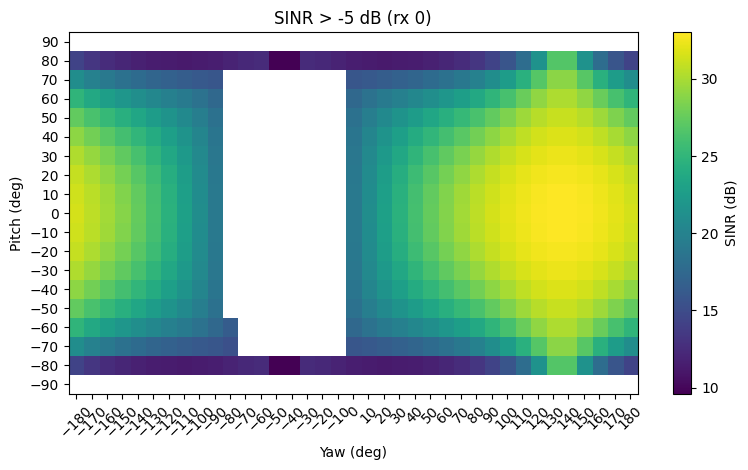

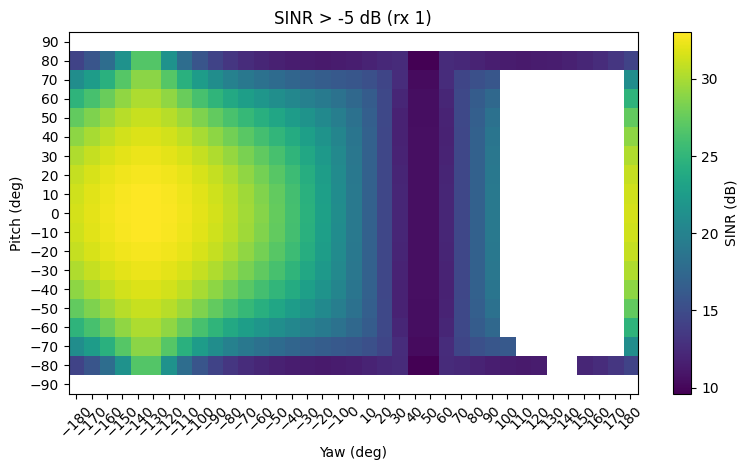

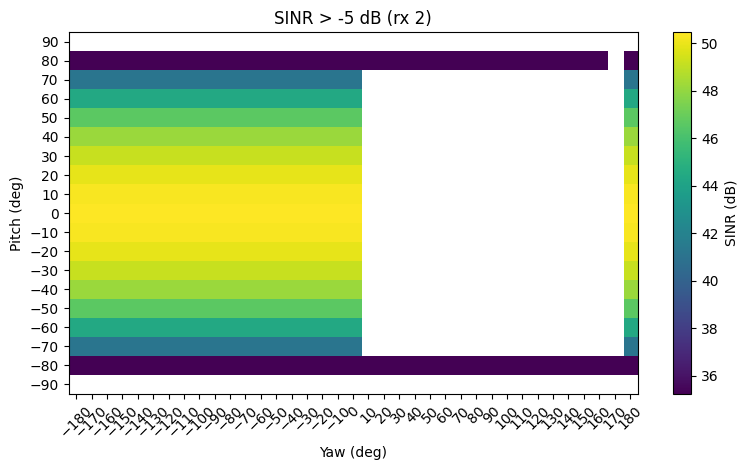

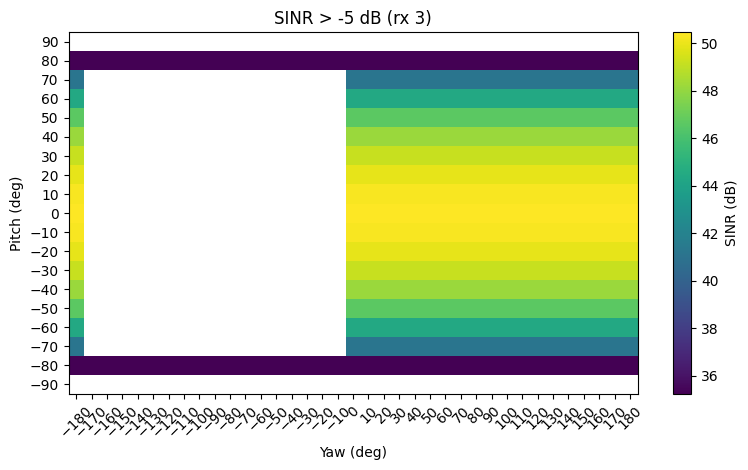

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# rotation_sinr_map: shape (x_dim, y_dim, 4) = (yaw, pitch, rx)
# 如果你的是 (pitch, yaw, rx) 需要 transpose，一会儿我也给你判断方法

yaw_deg_list = list(range(-180, 181, step_size))
pitch_deg_list = list(range(-90, 91, step_size))

x_dim = len(yaw_deg_list)   # 37
y_dim = len(pitch_deg_list) # 19

assert rotation_sinr_map.shape[:2] in [(x_dim, y_dim), (y_dim, x_dim)], \
    f"shape mismatch: got {rotation_sinr_map.shape}, expected (37,19,4) or (19,37,4)"

# 统一成 (yaw, pitch, rx)
if rotation_sinr_map.shape[0] == y_dim and rotation_sinr_map.shape[1] == x_dim:
    rotation_sinr_map = np.transpose(rotation_sinr_map, (1, 0, 2))

# 画图用 extent：让像素中心对齐到角度刻度（更“物理”）
# 每个格子宽度是 10°，所以边界要 +/-5°
yaw_step = yaw_deg_list[1] - yaw_deg_list[0]        # 10
pitch_step = pitch_deg_list[1] - pitch_deg_list[0]  # 10

extent = [
    yaw_deg_list[0] - yaw_step/2,      # left
    yaw_deg_list[-1] + yaw_step/2,     # right
    pitch_deg_list[0] - pitch_step/2,  # bottom
    pitch_deg_list[-1] + pitch_step/2  # top
]


import numpy as np
import matplotlib.pyplot as plt

threshold = -5  # dB

for rx in range(rotation_sinr_map.shape[2]):
    data = rotation_sinr_map[:, :, rx]  # (yaw, pitch)

    # 只保留 sinr > -5
    data_masked = np.ma.masked_less_equal(data, threshold)

    img = data_masked.T  # (pitch, yaw)

    fig, ax = plt.subplots(figsize=(8, 4.8))
    im = ax.imshow(
        img,
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest"
    )

    ax.set_title(f"SINR > {threshold} dB (rx {rx})")
    ax.set_xlabel("Yaw (deg)")
    ax.set_ylabel("Pitch (deg)")

    ax.set_xticks(yaw_deg_list)
    ax.set_yticks(pitch_deg_list)
    ax.tick_params(axis='x', labelrotation=45)

    # 👉 被 mask 的区域会显示为透明
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("SINR (dB)")

    plt.tight_layout()
    plt.show()


In [7]:
rotation_sinr_map.shape

(37, 19, 4)

In [8]:
rotation_sinr_map[0, np.argmax(rotation_sinr_map[0,:,0]), 0]

31.486528741573938

In [9]:
engine.

SyntaxError: invalid syntax (3358897293.py, line 1)